# TransTVDiag Evaluation


In [1]:
!pip install torch==2.1.1
!pip install dgl -f https://data.dgl.ai/wheels/torch-2.1/cu121/repo.html
!pip install scikit-learn
!pip install fasttext==0.9.2

Looking in indexes: https://artifactory.tcsbank.ru/artifactory/api/pypi/python-all/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 670.2/670.2 MB 14.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 126.8 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 41.4 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 126.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 102.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 162.1 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 12.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 21.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 58.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 92.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━

In [2]:
from argparse import Namespace
from pathlib import Path

import dgl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader

from core.model.MainModel import MainModel
from prepare_data import prepare_for_graphormer
from process.EventProcess import EventProcess

plt.rcParams['figure.figsize'] = (10, 8)
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 120)

Setting the default backend to "pytorch". You can change it in the ~/.dgl/config.json file or export the DGLBACKEND environment variable.  Valid options are: pytorch, mxnet, tensorflow (all lowercase)


DGL backend not selected or invalid.  Assuming PyTorch for now.


In [4]:
DATASET = 'gaia'
LABELS_FILE = 'label_15_85_corrected_index.csv'
CHECKPOINT_PATH = Path('logs') / DATASET / 'TransTVDiag-metric-trace-log.pt'
ONLY_METRICS_CHECKPOINT_PATH = Path('logs') / DATASET / 'TransTVDiag-metric.pt'
ONLY_LOGS_CHECKPOINT_PATH = Path('logs') / DATASET / 'TransTVDiag-log.pt'
ONLY_TRACES_CHECKPOINT_PATH = Path('logs') / DATASET / 'TransTVDiag-trace.pt'
OUTPUT_DIR = Path('logs') / DATASET / 'evaluation_artifacts'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

args = Namespace(
    dataset=DATASET,
    labels_file=LABELS_FILE,
    embedding_dim=128,
    graph_hidden=128,
    graph_out=32,
    num_heads=16,
    num_layers=2,
    attn_drop=0.0,
    linear_hidden=[64],
    reconstruct=True,
    aug_percent=0.2,
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Device: {DEVICE}')
print(f'Checkpoint: {CHECKPOINT_PATH.resolve()}')
print(f'Artifacts dir: {OUTPUT_DIR.resolve()}')

Device: cuda
Checkpoint: /workdir/TransTVDiag/logs/gaia/TransTVDiag-metric-trace-log.pt
Artifacts dir: /workdir/TransTVDiag/logs/gaia/evaluation_artifacts


In [5]:
import pickle
labels_df = pd.read_csv(Path('data') / DATASET / LABELS_FILE)
instance_names = sorted(list(set(list(labels_df['instance']))))
failure_type_names = sorted(list((set(list(labels_df['anomaly_type'])))))
# sorted(labels_df['anomaly_type'].unique().tolist())
# with open('data/gaia/events/nodes.pkl', 'rb') as f:
#         instance_names = pickle.load(f, encoding='bytes')
# # labels = pd.read_csv(label_path)
# failure_type_names = ['normal'] + labels_df['anomaly_type'].unique().tolist()

args.N_I = len(instance_names)
args.N_T = len(failure_type_names)
print('inctance num', len(instance_names))
print('failure type num', len(failure_type_names))
print('-------')
print(args)
print('-------')


instance_id_to_name = {idx: name for idx, name in enumerate(instance_names)}
failure_type_id_to_name = {idx: name for idx, name in enumerate(failure_type_names)}

test_meta = labels_df[labels_df['data_type'] == 'test'].reset_index(drop=True).copy()
print('Test samples:', len(test_meta))
print('Instance labels:', instance_id_to_name)
print('Failure type labels:', failure_type_id_to_name)

inctance num 10
failure type num 5
-------
Namespace(dataset='gaia', labels_file='label_15_85_corrected_index.csv', embedding_dim=128, graph_hidden=128, graph_out=32, num_heads=16, num_layers=2, attn_drop=0.0, linear_hidden=[64], reconstruct=True, aug_percent=0.2, N_I=10, N_T=5)
-------
Test samples: 13774
Instance labels: {0: 'dbservice1', 1: 'dbservice2', 2: 'logservice1', 3: 'logservice2', 4: 'mobservice1', 5: 'mobservice2', 6: 'redisservice1', 7: 'redisservice2', 8: 'webservice1', 9: 'webservice2'}
Failure type labels: {0: '[access permission denied exception]', 1: '[file moving program]', 2: '[login failure]', 3: '[memory_anomalies]', 4: '[normal memory freed label]'}


In [6]:
class NotebookLogger:
    def info(self, msg):
        pass
    def debug(self, msg):
        pass

def collate(samples):
    graphs, labels = map(list, zip(*samples))
    labels = torch.tensor(labels)
    return prepare_for_graphormer(graphs, labels)

processor = EventProcess(args, NotebookLogger())
_, test_data = processor.process(reconstruct=False)
test_loader = DataLoader(test_data, batch_size=1, shuffle=False, collate_fn=collate)

len(test_data)

13774

In [8]:
import torch
import pandas as pd


def build_predictions_df(
    args,
    CHECKPOINT_PATH,
    test_loader,
    test_meta,
    instance_names,
    failure_type_names,
    instance_id_to_name,
    failure_type_id_to_name,
    MainModel,
    DEVICE,
):
    model = MainModel(args).to(DEVICE)
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    model.load_state_dict(checkpoint["model"])
    model.eval()

    records = []

    for sample_idx, batch in enumerate(test_loader):
        (
            labels,
            metric_feat,
            trace_feat,
            log_feat,
            in_degree,
            out_degree,
            attn_mask,
            path_data,
            dist,
        ) = batch

        target_root_idx = labels[:, 0].item()
        target_type_idx = labels[:, 1].item()

        with torch.no_grad():
            _, root_logits, type_logits = model(
                metric_feat.to(DEVICE),
                trace_feat.to(DEVICE),
                log_feat.to(DEVICE),
                in_degree.to(DEVICE),
                out_degree.to(DEVICE),
                dist.to(DEVICE),
                path_data.to(DEVICE),
                attn_mask.to(DEVICE),
            )

        root_probs = torch.softmax(root_logits, dim=1).cpu()[0]
        type_probs = torch.softmax(type_logits, dim=1).cpu()[0]

        pred_root_idx = int(root_probs.argmax().item())
        pred_type_idx = int(type_probs.argmax().item())

        topk_root = min(5, len(instance_names))
        root_topk_scores, root_topk_indices = torch.topk(root_probs, k=topk_root)
        type_topk_scores, type_topk_indices = torch.topk(
            type_probs, k=len(failure_type_names)
        )

        meta = test_meta.iloc[sample_idx]
        records.append(
            {
                "sample_position": sample_idx,
                "data_index": int(meta["index"]),
                "datetime": meta["datetime"],
                "service": meta["service"],
                "message": meta["message"],
                "target_root_idx": target_root_idx,
                "target_root_name": instance_id_to_name[target_root_idx],
                "pred_root_idx": pred_root_idx,
                "pred_root_name": instance_id_to_name[pred_root_idx],
                "target_type_idx": target_type_idx,
                "target_type_name": failure_type_id_to_name[target_type_idx],
                "pred_type_idx": pred_type_idx,
                "pred_type_name": failure_type_id_to_name[pred_type_idx],
                "root_correct": pred_root_idx == target_root_idx,
                "type_correct": pred_type_idx == target_type_idx,
                "pred_root_confidence": float(root_probs[pred_root_idx].item()),
                "pred_type_confidence": float(type_probs[pred_type_idx].item()),
                "root_top5_indices": [int(x) for x in root_topk_indices.tolist()],
                "root_top5_names": [
                    instance_id_to_name[int(x)] for x in root_topk_indices.tolist()
                ],
                "root_top5_scores": [float(x) for x in root_topk_scores.tolist()],
                "type_ranked_indices": [int(x) for x in type_topk_indices.tolist()],
                "type_ranked_names": [
                    failure_type_id_to_name[int(x)] for x in type_topk_indices.tolist()
                ],
                "type_ranked_scores": [float(x) for x in type_topk_scores.tolist()],
            }
        )

    predictions_df = pd.DataFrame(records)
    return predictions_df

In [20]:
predictions_df = build_predictions_df(
    args=args,
    CHECKPOINT_PATH=CHECKPOINT_PATH,
    test_loader=test_loader,
    test_meta=test_meta,
    instance_names=instance_names,
    failure_type_names=failure_type_names,
    instance_id_to_name=instance_id_to_name,
    failure_type_id_to_name=failure_type_id_to_name,
    MainModel=MainModel,
    DEVICE=DEVICE,
)

predictions_df.head()

From Main Model:  {'log', 'trace', 'metric'}


,sample_position,data_index,datetime,service,message,target_root_idx,target_root_name,pred_root_idx,pred_root_name,target_type_idx,target_type_name,pred_type_idx,pred_type_name,root_correct,type_correct,pred_root_confidence,pred_type_confidence,root_top5_indices,root_top5_names,root_top5_scores,type_ranked_indices,type_ranked_names,type_ranked_scores
0,0,2431,2021-07-05,mobservice,"2021-07-05 21:42:01,380 | WARNING | 0.0.0.1 | 172.17.0.5 | mobservice1 | 86ec9abb15b5ff80 | wait for 11 seconds for ...",4,mobservice1,4,mobservice1,2,[login failure],2,[login failure],True,True,0.999914,0.999994,"[4, 5, 8, 7, 0]","[mobservice1, mobservice2, webservice1, redisservice2, dbservice1]","[0.999914288520813, 6.592032877961174e-05, 8.936001904658042e-06, 3.4809122553269845e-06, 2.916104222094873e-06]","[2, 0, 1, 4, 3]","[[login failure], [access permission denied exception], [file moving program], [normal memory freed label], [memory_...","[0.9999939203262329, 1.618591568330885e-06, 1.6151838053701795e-06, 1.5698478819103912e-06, 1.2171112757641822e-06]"
1,1,2432,2021-07-05,mobservice,"2021-07-05 21:42:32,616 | WARNING | 0.0.0.4 | 172.17.0.2 | mobservice2 | b13e6cdef1c77e0f | wait for 11 seconds for ...",5,mobservice2,5,mobservice2,2,[login failure],2,[login failure],True,True,0.999997,0.999998,"[5, 4, 3, 6, 9]","[mobservice2, mobservice1, logservice2, redisservice1, webservice2]","[0.9999972581863403, 2.058532572846161e-06, 3.6665318248196854e-07, 1.0296923136365876e-07, 8.610887647364507e-08]","[2, 3, 4, 0, 1]","[[login failure], [memory_anomalies], [normal memory freed label], [access permission denied exception], [file movin...","[0.9999979734420776, 8.179923725037952e-07, 5.073641773378768e-07, 5.02759974096989e-07, 2.293502632255695e-07]"
2,2,2433,2021-07-05,mobservice,"2021-07-05 21:45:00,329 | WARNING | 0.0.0.1 | 172.17.0.5 | mobservice1 | 5930623f2070d5ba | wait for 11 seconds for ...",4,mobservice1,4,mobservice1,2,[login failure],2,[login failure],True,True,0.999855,0.999951,"[4, 5, 8, 7, 0]","[mobservice1, mobservice2, webservice1, redisservice2, dbservice1]","[0.9998552799224854, 7.668261969229206e-05, 2.8311780624790117e-05, 1.3509931704902556e-05, 1.091548620024696e-05]","[2, 1, 0, 4, 3]","[[login failure], [file moving program], [access permission denied exception], [normal memory freed label], [memory_...","[0.9999514818191528, 1.5133462511585094e-05, 1.2504715414252132e-05, 1.180701201519696e-05, 9.104664059123024e-06]"
3,3,2434,2021-07-05,mobservice,"2021-07-05 21:49:00,904 | WARNING | 0.0.0.1 | 172.17.0.5 | mobservice1 | 2375b8b74da928f8 | wait for 11 seconds for ...",4,mobservice1,4,mobservice1,2,[login failure],2,[login failure],True,True,0.999978,0.999968,"[4, 5, 8, 0, 7]","[mobservice1, mobservice2, webservice1, dbservice1, redisservice2]","[0.9999775886535645, 8.348110895894933e-06, 5.1018041631323285e-06, 2.7101214072899893e-06, 2.394256853222032e-06]","[2, 1, 0, 4, 3]","[[login failure], [file moving program], [access permission denied exception], [normal memory freed label], [memory_...","[0.9999679327011108, 9.020796824188437e-06, 8.656033969600685e-06, 7.766770067973994e-06, 6.609557203773875e-06]"
4,4,2435,2021-07-05,mobservice,"2021-07-05 21:50:37,731 | WARNING | 0.0.0.4 | 172.17.0.2 | mobservice2 | 286d315a73923371 | wait for 11 seconds for ...",5,mobservice2,4,mobservice1,2,[login failure],2,[login failure],False,True,0.999655,0.999847,"[4, 5, 8, 0, 7]","[mobservice1, mobservice2, webservice1, dbservice1, redisservice2]","[0.99965500831604, 0.0001422630448359996, 9.129815589403734e-05, 3.451359225437045e-05, 2.8413534892024472e-05]","[2, 1, 0, 4, 3]","[[login failure], [file moving program], [access permission denied exception], [normal memory freed label], [memory_...","[0.9998469352722168, 4.387031731312163e-05, 4.11245200666599e-05, 3.510763417580165e-05, 3.293188274255954e-05]"


In [17]:
# model = MainModel(args).to(DEVICE)
# checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
# model.load_state_dict(checkpoint['model'])
# model.eval()

# records = []

# for sample_idx, batch in enumerate(test_loader):
#     labels, metric_feat, trace_feat, log_feat, in_degree, out_degree, attn_mask, path_data, dist = batch

#     target_root_idx = labels[:, 0].item()
#     target_type_idx = labels[:, 1].item()

#     with torch.no_grad():
#         _, root_logits, type_logits = model(
#             metric_feat.to(DEVICE),
#             trace_feat.to(DEVICE),
#             log_feat.to(DEVICE),
#             in_degree.to(DEVICE),
#             out_degree.to(DEVICE),
#             dist.to(DEVICE),
#             path_data.to(DEVICE),
#             attn_mask.to(DEVICE),
#         )

#     root_probs = torch.softmax(root_logits, dim=1).cpu()[0]
#     type_probs = torch.softmax(type_logits, dim=1).cpu()[0]

#     pred_root_idx = int(root_probs.argmax().item())
#     pred_type_idx = int(type_probs.argmax().item())

#     topk_root = min(5, len(instance_names))
#     root_topk_scores, root_topk_indices = torch.topk(root_probs, k=topk_root)
#     type_topk_scores, type_topk_indices = torch.topk(type_probs, k=len(failure_type_names))

#     meta = test_meta.iloc[sample_idx]
#     records.append({
#         'sample_position': sample_idx,
#         'data_index': int(meta['index']),
#         'datetime': meta['datetime'],
#         'service': meta['service'],
#         'message': meta['message'],
#         'target_root_idx': target_root_idx,
#         'target_root_name': instance_id_to_name[target_root_idx],
#         'pred_root_idx': pred_root_idx,
#         'pred_root_name': instance_id_to_name[pred_root_idx],
#         'target_type_idx': target_type_idx,
#         'target_type_name': failure_type_id_to_name[target_type_idx],
#         'pred_type_idx': pred_type_idx,
#         'pred_type_name': failure_type_id_to_name[pred_type_idx],
#         'root_correct': pred_root_idx == target_root_idx,
#         'type_correct': pred_type_idx == target_type_idx,
#         'pred_root_confidence': float(root_probs[pred_root_idx].item()),
#         'pred_type_confidence': float(type_probs[pred_type_idx].item()),
#         'root_top5_indices': [int(x) for x in root_topk_indices.tolist()],
#         'root_top5_names': [instance_id_to_name[int(x)] for x in root_topk_indices.tolist()],
#         'root_top5_scores': [float(x) for x in root_topk_scores.tolist()],
#         'type_ranked_indices': [int(x) for x in type_topk_indices.tolist()],
#         'type_ranked_names': [failure_type_id_to_name[int(x)] for x in type_topk_indices.tolist()],
#         'type_ranked_scores': [float(x) for x in type_topk_scores.tolist()],
#     })

# predictions_df = pd.DataFrame(records)
# predictions_df.head()

From Main Model:  {'log', 'trace', 'metric'}


,sample_position,data_index,datetime,service,message,target_root_idx,target_root_name,pred_root_idx,pred_root_name,target_type_idx,target_type_name,pred_type_idx,pred_type_name,root_correct,type_correct,pred_root_confidence,pred_type_confidence,root_top5_indices,root_top5_names,root_top5_scores,type_ranked_indices,type_ranked_names,type_ranked_scores
0,0,2431,2021-07-05,mobservice,"2021-07-05 21:42:01,380 | WARNING | 0.0.0.1 | 172.17.0.5 | mobservice1 | 86ec9abb15b5ff80 | wait for 11 seconds for ...",4,mobservice1,4,mobservice1,2,[login failure],2,[login failure],True,True,0.999914,0.999994,"[4, 5, 8, 7, 0]","[mobservice1, mobservice2, webservice1, redisservice2, dbservice1]","[0.999914288520813, 6.592032877961174e-05, 8.936001904658042e-06, 3.4809122553269845e-06, 2.916104222094873e-06]","[2, 0, 1, 4, 3]","[[login failure], [access permission denied exception], [file moving program], [normal memory freed label], [memory_...","[0.9999939203262329, 1.618591568330885e-06, 1.6151838053701795e-06, 1.5698478819103912e-06, 1.2171112757641822e-06]"
1,1,2432,2021-07-05,mobservice,"2021-07-05 21:42:32,616 | WARNING | 0.0.0.4 | 172.17.0.2 | mobservice2 | b13e6cdef1c77e0f | wait for 11 seconds for ...",5,mobservice2,5,mobservice2,2,[login failure],2,[login failure],True,True,0.999997,0.999998,"[5, 4, 3, 6, 9]","[mobservice2, mobservice1, logservice2, redisservice1, webservice2]","[0.9999972581863403, 2.058532572846161e-06, 3.6665318248196854e-07, 1.0296923136365876e-07, 8.610887647364507e-08]","[2, 3, 4, 0, 1]","[[login failure], [memory_anomalies], [normal memory freed label], [access permission denied exception], [file movin...","[0.9999979734420776, 8.179923725037952e-07, 5.073641773378768e-07, 5.02759974096989e-07, 2.293502632255695e-07]"
2,2,2433,2021-07-05,mobservice,"2021-07-05 21:45:00,329 | WARNING | 0.0.0.1 | 172.17.0.5 | mobservice1 | 5930623f2070d5ba | wait for 11 seconds for ...",4,mobservice1,4,mobservice1,2,[login failure],2,[login failure],True,True,0.999855,0.999951,"[4, 5, 8, 7, 0]","[mobservice1, mobservice2, webservice1, redisservice2, dbservice1]","[0.9998552799224854, 7.668261969229206e-05, 2.8311780624790117e-05, 1.3509931704902556e-05, 1.091548620024696e-05]","[2, 1, 0, 4, 3]","[[login failure], [file moving program], [access permission denied exception], [normal memory freed label], [memory_...","[0.9999514818191528, 1.5133462511585094e-05, 1.2504715414252132e-05, 1.180701201519696e-05, 9.104664059123024e-06]"
3,3,2434,2021-07-05,mobservice,"2021-07-05 21:49:00,904 | WARNING | 0.0.0.1 | 172.17.0.5 | mobservice1 | 2375b8b74da928f8 | wait for 11 seconds for ...",4,mobservice1,4,mobservice1,2,[login failure],2,[login failure],True,True,0.999978,0.999968,"[4, 5, 8, 0, 7]","[mobservice1, mobservice2, webservice1, dbservice1, redisservice2]","[0.9999775886535645, 8.348110895894933e-06, 5.1018041631323285e-06, 2.7101214072899893e-06, 2.394256853222032e-06]","[2, 1, 0, 4, 3]","[[login failure], [file moving program], [access permission denied exception], [normal memory freed label], [memory_...","[0.9999679327011108, 9.020796824188437e-06, 8.656033969600685e-06, 7.766770067973994e-06, 6.609557203773875e-06]"
4,4,2435,2021-07-05,mobservice,"2021-07-05 21:50:37,731 | WARNING | 0.0.0.4 | 172.17.0.2 | mobservice2 | 286d315a73923371 | wait for 11 seconds for ...",5,mobservice2,4,mobservice1,2,[login failure],2,[login failure],False,True,0.999655,0.999847,"[4, 5, 8, 0, 7]","[mobservice1, mobservice2, webservice1, dbservice1, redisservice2]","[0.99965500831604, 0.0001422630448359996, 9.129815589403734e-05, 3.451359225437045e-05, 2.8413534892024472e-05]","[2, 1, 0, 4, 3]","[[login failure], [file moving program], [access permission denied exception], [normal memory freed label], [memory_...","[0.9998469352722168, 4.387031731312163e-05, 4.11245200666599e-05, 3.510763417580165e-05, 3.293188274255954e-05]"


In [21]:
predictions_csv = OUTPUT_DIR / 'test_predictions.csv'
predictions_parquet = OUTPUT_DIR / 'test_predictions.parquet'

predictions_df.to_csv(predictions_csv, index=False)
print(f'Saved: {predictions_csv.resolve()}')

# try:
#     predictions_df.to_parquet(predictions_parquet, index=False)
#     print(f'Saved: {predictions_parquet.resolve()}')
# except Exception as exc:
#     print(f'Parquet export skipped: {exc}')

Saved: /workdir/TransTVDiag/logs/gaia/evaluation_artifacts/test_predictions.csv


In [22]:
root_report = classification_report(
    predictions_df['target_root_name'],
    predictions_df['pred_root_name'],
    labels=instance_names,
    output_dict=True,
    zero_division=0,
)
type_report = classification_report(
    predictions_df['target_type_name'],
    predictions_df['pred_type_name'],
    labels=failure_type_names,
    output_dict=True,
    zero_division=0,
)

root_report_df = pd.DataFrame(root_report).transpose()
type_report_df = pd.DataFrame(type_report).transpose()

root_report_df.to_csv(OUTPUT_DIR / 'classification_report_rcl.csv')
type_report_df.to_csv(OUTPUT_DIR / 'classification_report_fti.csv')

display(root_report_df)
display(type_report_df)

,precision,recall,f1-score,support
dbservice1,0.062500,0.014493,0.023529,69.00000
dbservice2,0.145161,0.103448,0.120805,87.00000
logservice1,0.064103,0.090909,0.075188,55.00000
logservice2,0.040000,0.039216,0.039604,51.00000
mobservice1,0.855952,0.929973,0.891429,6626.00000
mobservice2,0.921653,0.840139,0.879010,6637.00000
redisservice1,0.074830,0.234043,0.113402,47.00000
redisservice2,0.077922,0.125000,0.096000,48.00000
webservice1,0.125000,0.038462,0.058824,78.00000
webservice2,0.154930,0.144737,0.149660,76.00000


,precision,recall,f1-score,support
[access permission denied exception],0.000000,0.000000,0.000000,15.00000
[file moving program],0.139535,0.162162,0.150000,37.00000
[login failure],0.999087,0.999543,0.999315,13143.00000
[memory_anomalies],0.915517,0.941489,0.928322,564.00000
[normal memory freed label],0.000000,0.000000,0.000000,15.00000
accuracy,0.992740,0.992740,0.992740,0.99274
macro avg,0.410828,0.420639,0.415527,13774.00000
weighted avg,0.991180,0.992740,0.991950,13774.00000


In [23]:
print('RCL report')
print(classification_report(
    predictions_df['target_root_name'],
    predictions_df['pred_root_name'],
    labels=instance_names,
    zero_division=0,
))

print('FTI report')
print(classification_report(
    predictions_df['target_type_name'],
    predictions_df['pred_type_name'],
    labels=failure_type_names,
    zero_division=0,
))

RCL report
               precision    recall  f1-score   support

   dbservice1       0.06      0.01      0.02        69
   dbservice2       0.15      0.10      0.12        87
  logservice1       0.06      0.09      0.08        55
  logservice2       0.04      0.04      0.04        51
  mobservice1       0.86      0.93      0.89      6626
  mobservice2       0.92      0.84      0.88      6637
redisservice1       0.07      0.23      0.11        47
redisservice2       0.08      0.12      0.10        48
  webservice1       0.12      0.04      0.06        78
  webservice2       0.15      0.14      0.15        76

     accuracy                           0.86     13774
    macro avg       0.25      0.26      0.24     13774
 weighted avg       0.86      0.86      0.86     13774

FTI report
                                      precision    recall  f1-score   support

[access permission denied exception]       0.00      0.00      0.00        15
               [file moving program]       0.14 

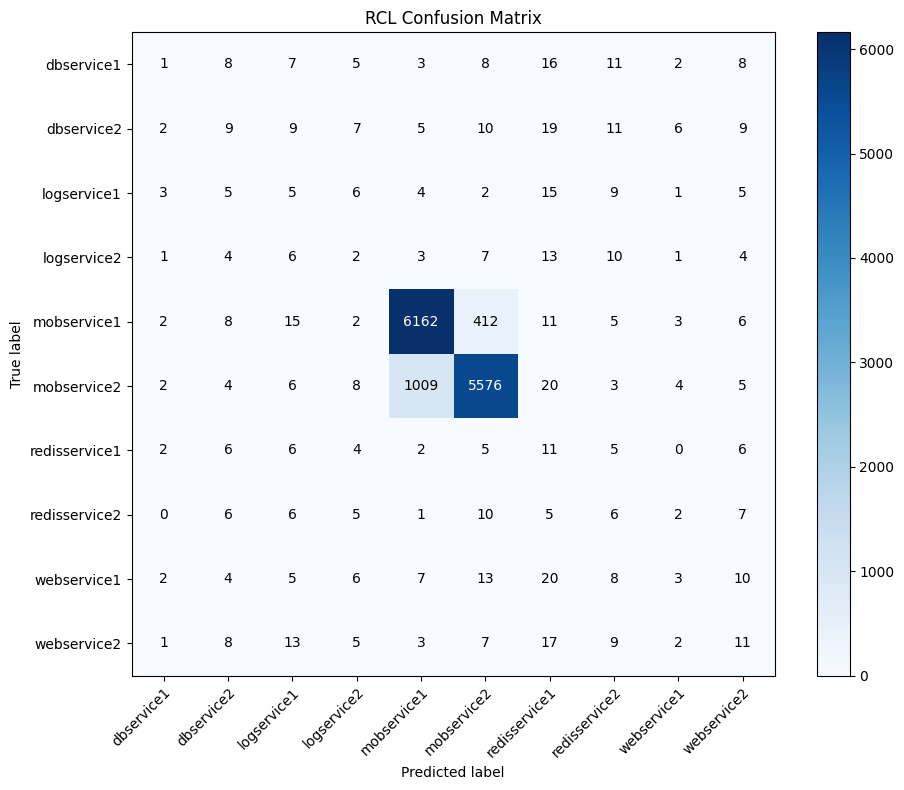

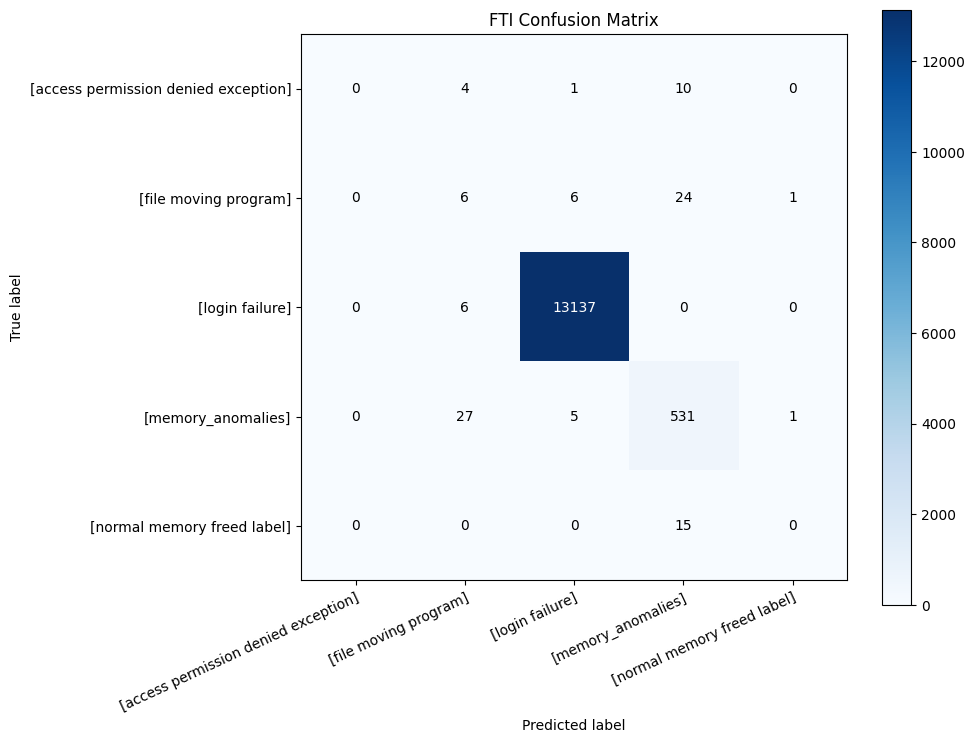

In [24]:
def plot_confusion_matrix(cm, labels, title, rotate_x=45):
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        title=title,
        ylabel='True label',
        xlabel='Predicted label',
    )
    plt.setp(ax.get_xticklabels(), rotation=rotate_x, ha='right', rotation_mode='anchor')

    threshold = cm.max() / 2.0 if cm.size else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                format(cm[i, j], 'd'),
                ha='center',
                va='center',
                color='white' if cm[i, j] > threshold else 'black',
            )
    fig.tight_layout()
    return fig

root_cm = confusion_matrix(
    predictions_df['target_root_name'],
    predictions_df['pred_root_name'],
    labels=instance_names,
)
type_cm = confusion_matrix(
    predictions_df['target_type_name'],
    predictions_df['pred_type_name'],
    labels=failure_type_names,
)

pd.DataFrame(root_cm, index=instance_names, columns=instance_names).to_csv(OUTPUT_DIR / 'confusion_matrix_rcl.csv')
pd.DataFrame(type_cm, index=failure_type_names, columns=failure_type_names).to_csv(OUTPUT_DIR / 'confusion_matrix_fti.csv')

fig_root = plot_confusion_matrix(root_cm, instance_names, 'RCL Confusion Matrix')
fig_type = plot_confusion_matrix(type_cm, failure_type_names, 'FTI Confusion Matrix', rotate_x=25)

fig_root.savefig(OUTPUT_DIR / 'confusion_matrix_rcl.png', bbox_inches='tight')
fig_type.savefig(OUTPUT_DIR / 'confusion_matrix_fti.png', bbox_inches='tight')
plt.show()

In [25]:
summary = pd.DataFrame([
    {
        'task': 'RCL',
        'accuracy': (predictions_df['target_root_name'] == predictions_df['pred_root_name']).mean(),
        'macro_f1': root_report_df.loc['macro avg', 'f1-score'],
        'weighted_f1': root_report_df.loc['weighted avg', 'f1-score'],
    },
    {
        'task': 'FTI',
        'accuracy': (predictions_df['target_type_name'] == predictions_df['pred_type_name']).mean(),
        'macro_f1': type_report_df.loc['macro avg', 'f1-score'],
        'weighted_f1': type_report_df.loc['weighted avg', 'f1-score'],
    },
])

summary.to_csv(OUTPUT_DIR / 'metrics_summary.csv', index=False)
summary

,task,accuracy,macro_f1,weighted_f1
0,RCL,0.85567,0.244745,0.855582
1,FTI,0.99274,0.415527,0.991950


## Only metrics evaluation

In [27]:
only_metric_args = Namespace(
    dataset=DATASET,
    labels_file=LABELS_FILE,
    embedding_dim=128,
    graph_hidden=128,
    graph_out=32,
    num_heads=16,
    num_layers=2,
    attn_drop=0.0,
    linear_hidden=[64],
    reconstruct=True,
    aug_percent=0.2,
    N_I = len(instance_names),
    N_T = len(failure_type_names),
    modalities = "metric"
)

only_metrics_predictions_df = build_predictions_df(
    args=only_metric_args,
    CHECKPOINT_PATH=ONLY_METRICS_CHECKPOINT_PATH,
    test_loader=test_loader,
    test_meta=test_meta,
    instance_names=instance_names,
    failure_type_names=failure_type_names,
    instance_id_to_name=instance_id_to_name,
    failure_type_id_to_name=failure_type_id_to_name,
    MainModel=MainModel,
    DEVICE=DEVICE,
)

only_metrics_predictions_df.head()

From Main Model:  {'metric'}


,sample_position,data_index,datetime,service,message,target_root_idx,target_root_name,pred_root_idx,pred_root_name,target_type_idx,target_type_name,pred_type_idx,pred_type_name,root_correct,type_correct,pred_root_confidence,pred_type_confidence,root_top5_indices,root_top5_names,root_top5_scores,type_ranked_indices,type_ranked_names,type_ranked_scores
0,0,2431,2021-07-05,mobservice,"2021-07-05 21:42:01,380 | WARNING | 0.0.0.1 | 172.17.0.5 | mobservice1 | 86ec9abb15b5ff80 | wait for 11 seconds for ...",4,mobservice1,4,mobservice1,2,[login failure],2,[login failure],True,True,0.626888,1.000000,"[4, 5, 1, 2, 6]","[mobservice1, mobservice2, dbservice2, logservice1, redisservice1]","[0.6268879175186157, 0.3730875253677368, 1.4435851880989503e-05, 2.6453515147295548e-06, 2.4469472919008695e-06]","[2, 3, 4, 0, 1]","[[login failure], [memory_anomalies], [normal memory freed label], [access permission denied exception], [file movin...","[0.9999995231628418, 4.6194207925509545e-07, 2.023543999030153e-08, 5.640546623525422e-13, 1.064484871776683e-13]"
1,1,2432,2021-07-05,mobservice,"2021-07-05 21:42:32,616 | WARNING | 0.0.0.4 | 172.17.0.2 | mobservice2 | b13e6cdef1c77e0f | wait for 11 seconds for ...",5,mobservice2,4,mobservice1,2,[login failure],2,[login failure],False,True,0.657098,1.000000,"[4, 5, 1, 2, 6]","[mobservice1, mobservice2, dbservice2, logservice1, redisservice1]","[0.6570982336997986, 0.3428809642791748, 1.2684556168096606e-05, 2.121701072610449e-06, 1.9517563032422913e-06]","[2, 3, 4, 0, 1]","[[login failure], [memory_anomalies], [normal memory freed label], [access permission denied exception], [file movin...","[0.9999996423721313, 3.253564955230104e-07, 1.4143977544733843e-08, 3.425526735097856e-13, 6.100185596458543e-14]"
2,2,2433,2021-07-05,mobservice,"2021-07-05 21:45:00,329 | WARNING | 0.0.0.1 | 172.17.0.5 | mobservice1 | 5930623f2070d5ba | wait for 11 seconds for ...",4,mobservice1,4,mobservice1,2,[login failure],2,[login failure],True,True,0.615592,1.000000,"[4, 5, 1, 2, 6]","[mobservice1, mobservice2, dbservice2, logservice1, redisservice1]","[0.6155922412872314, 0.38438573479652405, 1.3063410733593628e-05, 2.276406576129375e-06, 2.169834942833404e-06]","[2, 3, 4, 0, 1]","[[login failure], [memory_anomalies], [normal memory freed label], [access permission denied exception], [file movin...","[0.9999996423721313, 3.805014614499669e-07, 1.6851679163210065e-08, 4.2890566315581524e-13, 7.94351157117415e-14]"
3,3,2434,2021-07-05,mobservice,"2021-07-05 21:49:00,904 | WARNING | 0.0.0.1 | 172.17.0.5 | mobservice1 | 2375b8b74da928f8 | wait for 11 seconds for ...",4,mobservice1,4,mobservice1,2,[login failure],2,[login failure],True,True,0.869796,0.999999,"[4, 5, 1, 2, 6]","[mobservice1, mobservice2, dbservice2, logservice1, redisservice1]","[0.8697956204414368, 0.13018688559532166, 1.0174104318139143e-05, 2.6801910735230194e-06, 2.192826059399522e-06]","[2, 3, 4, 0, 1]","[[login failure], [memory_anomalies], [normal memory freed label], [access permission denied exception], [file movin...","[0.9999991655349731, 8.509784947818844e-07, 3.6297521432970825e-08, 6.652628751699363e-13, 1.2019175260093162e-13]"
4,4,2435,2021-07-05,mobservice,"2021-07-05 21:50:37,731 | WARNING | 0.0.0.4 | 172.17.0.2 | mobservice2 | 286d315a73923371 | wait for 11 seconds for ...",5,mobservice2,4,mobservice1,2,[login failure],2,[login failure],False,True,0.855779,0.999999,"[4, 5, 1, 2, 6]","[mobservice1, mobservice2, dbservice2, logservice1, redisservice1]","[0.8557794094085693, 0.14420185983181, 1.133498881245032e-05, 2.641549826876144e-06, 2.166181957363733e-06]","[2, 3, 4, 0, 1]","[[login failure], [memory_anomalies], [normal memory freed label], [access permission denied exception], [file movin...","[0.9999992847442627, 7.407185762531299e-07, 3.168548445842134e-08, 6.012007298245026e-13, 1.0742729812272464e-13]"


In [29]:
only_metrics_root_report = classification_report(
    only_metrics_predictions_df['target_root_name'],
    only_metrics_predictions_df['pred_root_name'],
    labels=instance_names,
    output_dict=True,
    zero_division=0,
)
only_metrics_type_report = classification_report(
    only_metrics_predictions_df['target_type_name'],
    only_metrics_predictions_df['pred_type_name'],
    labels=failure_type_names,
    output_dict=True,
    zero_division=0,
)

only_metrics_root_report_df = pd.DataFrame(only_metrics_root_report).transpose()
only_metrics_type_report_df = pd.DataFrame(only_metrics_type_report).transpose()

only_metrics_root_report_df.to_csv(OUTPUT_DIR / 'only_metrics_classification_report_rcl.csv')
only_metrics_type_report_df.to_csv(OUTPUT_DIR / 'only_metrics_classification_report_fti.csv')

display(only_metrics_root_report_df)
display(only_metrics_type_report_df)

,precision,recall,f1-score,support
dbservice1,0.000000,0.000000,0.000000,69.000000
dbservice2,0.000000,0.000000,0.000000,87.000000
logservice1,0.000000,0.000000,0.000000,55.000000
logservice2,0.000000,0.000000,0.000000,51.000000
mobservice1,0.491714,0.380622,0.429094,6626.000000
mobservice2,0.467206,0.608558,0.528596,6637.000000
redisservice1,0.000000,0.000000,0.000000,47.000000
redisservice2,0.000000,0.000000,0.000000,48.000000
webservice1,0.000000,0.000000,0.000000,78.000000
webservice2,0.000000,0.000000,0.000000,76.000000


,precision,recall,f1-score,support
[access permission denied exception],0.000000,0.000000,0.000000,15.000000
[file moving program],0.000000,0.000000,0.000000,37.000000
[login failure],0.954189,1.000000,0.976558,13143.000000
[memory_anomalies],0.000000,0.000000,0.000000,564.000000
[normal memory freed label],0.000000,0.000000,0.000000,15.000000
accuracy,0.954189,0.954189,0.954189,0.954189
macro avg,0.190838,0.200000,0.195312,13774.000000
weighted avg,0.910477,0.954189,0.931821,13774.000000


## Only logs evaluation

In [30]:
only_logs_args = Namespace(
    dataset=DATASET,
    labels_file=LABELS_FILE,
    embedding_dim=128,
    graph_hidden=128,
    graph_out=32,
    num_heads=16,
    num_layers=2,
    attn_drop=0.0,
    linear_hidden=[64],
    reconstruct=True,
    aug_percent=0.2,
    N_I = len(instance_names),
    N_T = len(failure_type_names),
    modalities = "log"
)

only_logs_predictions_df = build_predictions_df(
    args=only_logs_args,
    CHECKPOINT_PATH=ONLY_LOGS_CHECKPOINT_PATH,
    test_loader=test_loader,
    test_meta=test_meta,
    instance_names=instance_names,
    failure_type_names=failure_type_names,
    instance_id_to_name=instance_id_to_name,
    failure_type_id_to_name=failure_type_id_to_name,
    MainModel=MainModel,
    DEVICE=DEVICE,
)

only_logs_predictions_df.head()

From Main Model:  {'log'}


,sample_position,data_index,datetime,service,message,target_root_idx,target_root_name,pred_root_idx,pred_root_name,target_type_idx,target_type_name,pred_type_idx,pred_type_name,root_correct,type_correct,pred_root_confidence,pred_type_confidence,root_top5_indices,root_top5_names,root_top5_scores,type_ranked_indices,type_ranked_names,type_ranked_scores
0,0,2431,2021-07-05,mobservice,"2021-07-05 21:42:01,380 | WARNING | 0.0.0.1 | 172.17.0.5 | mobservice1 | 86ec9abb15b5ff80 | wait for 11 seconds for ...",4,mobservice1,4,mobservice1,2,[login failure],2,[login failure],True,True,0.523550,0.999984,"[4, 5, 0, 6, 9]","[mobservice1, mobservice2, dbservice1, redisservice1, webservice2]","[0.5235496163368225, 0.47622236609458923, 6.082044274080545e-05, 4.9768135795602575e-05, 3.3728771086316556e-05]","[2, 4, 3, 1, 0]","[[login failure], [normal memory freed label], [memory_anomalies], [file moving program], [access permission denied ...","[0.9999837875366211, 9.371119631396141e-06, 6.4046544139273465e-06, 3.0698919317728723e-07, 2.0898539787594927e-07]"
1,1,2432,2021-07-05,mobservice,"2021-07-05 21:42:32,616 | WARNING | 0.0.0.4 | 172.17.0.2 | mobservice2 | b13e6cdef1c77e0f | wait for 11 seconds for ...",5,mobservice2,4,mobservice1,2,[login failure],2,[login failure],False,True,0.521077,0.999990,"[4, 5, 0, 6, 9]","[mobservice1, mobservice2, dbservice1, redisservice1, webservice2]","[0.5210766792297363, 0.47875383496284485, 4.31762782682199e-05, 3.692175596370362e-05, 2.4732273232075386e-05]","[2, 4, 3, 1, 0]","[[login failure], [normal memory freed label], [memory_anomalies], [file moving program], [access permission denied ...","[0.9999897480010986, 5.920210242038593e-06, 3.960338290198706e-06, 2.2297638224699767e-07, 1.4108857726569113e-07]"
2,2,2433,2021-07-05,mobservice,"2021-07-05 21:45:00,329 | WARNING | 0.0.0.1 | 172.17.0.5 | mobservice1 | 5930623f2070d5ba | wait for 11 seconds for ...",4,mobservice1,4,mobservice1,2,[login failure],2,[login failure],True,True,0.531915,0.999990,"[4, 5, 0, 6, 9]","[mobservice1, mobservice2, dbservice1, redisservice1, webservice2]","[0.5319146513938904, 0.4679145812988281, 4.5215470890980214e-05, 3.7285572034306824e-05, 2.511920320102945e-05]","[2, 4, 3, 1, 0]","[[login failure], [normal memory freed label], [memory_anomalies], [file moving program], [access permission denied ...","[0.9999896287918091, 6.04814840698964e-06, 3.9931201172294095e-06, 2.1094413682476443e-07, 1.3550277344620554e-07]"
3,3,2434,2021-07-05,mobservice,"2021-07-05 21:49:00,904 | WARNING | 0.0.0.1 | 172.17.0.5 | mobservice1 | 2375b8b74da928f8 | wait for 11 seconds for ...",4,mobservice1,4,mobservice1,2,[login failure],2,[login failure],True,True,0.537597,0.999991,"[4, 5, 0, 6, 9]","[mobservice1, mobservice2, dbservice1, redisservice1, webservice2]","[0.5375970602035522, 0.4622582495212555, 3.946527431253344e-05, 3.18184174830094e-05, 2.1144132915651426e-05]","[2, 4, 3, 1, 0]","[[login failure], [normal memory freed label], [memory_anomalies], [file moving program], [access permission denied ...","[0.9999914169311523, 5.008890184399206e-06, 3.2773696148069575e-06, 1.504161843968177e-07, 9.985031823589452e-08]"
4,4,2435,2021-07-05,mobservice,"2021-07-05 21:50:37,731 | WARNING | 0.0.0.4 | 172.17.0.2 | mobservice2 | 286d315a73923371 | wait for 11 seconds for ...",5,mobservice2,4,mobservice1,2,[login failure],2,[login failure],False,True,0.512227,0.999988,"[4, 5, 0, 6, 9]","[mobservice1, mobservice2, dbservice1, redisservice1, webservice2]","[0.512226939201355, 0.48759734630584717, 4.472351793083362e-05, 3.850477150990628e-05, 2.5382256353623234e-05]","[2, 4, 3, 1, 0]","[[login failure], [normal memory freed label], [memory_anomalies], [file moving program], [access permission denied ...","[0.9999884366989136, 6.613709047087468e-06, 4.52172571385745e-06, 2.216416987721459e-07, 1.4912056656157802e-07]"


In [31]:
only_logs_root_report = classification_report(
    only_logs_predictions_df['target_root_name'],
    only_logs_predictions_df['pred_root_name'],
    labels=instance_names,
    output_dict=True,
    zero_division=0,
)
only_logs_type_report = classification_report(
    only_logs_predictions_df['target_type_name'],
    only_logs_predictions_df['pred_type_name'],
    labels=failure_type_names,
    output_dict=True,
    zero_division=0,
)

only_logs_root_report_df = pd.DataFrame(only_logs_root_report).transpose()
only_logs_type_report_df = pd.DataFrame(only_logs_type_report).transpose()

only_logs_root_report_df.to_csv(OUTPUT_DIR / 'only_logs_classification_report_rcl.csv')
only_logs_type_report_df.to_csv(OUTPUT_DIR / 'only_logs_classification_report_fti.csv')

display(only_logs_root_report_df)
display(only_logs_type_report_df)

,precision,recall,f1-score,support
dbservice1,0.000000,0.000000,0.000000,69.00000
dbservice2,0.166667,0.011494,0.021505,87.00000
logservice1,0.000000,0.000000,0.000000,55.00000
logservice2,0.000000,0.000000,0.000000,51.00000
mobservice1,0.492353,0.957139,0.650228,6626.00000
mobservice2,0.497317,0.041886,0.077265,6637.00000
redisservice1,0.250000,0.021277,0.039216,47.00000
redisservice2,0.214286,0.062500,0.096774,48.00000
webservice1,0.153846,0.358974,0.215385,78.00000
webservice2,0.096491,0.144737,0.115789,76.00000


,precision,recall,f1-score,support
[access permission denied exception],0.000000,0.000000,0.000000,15.000000
[file moving program],0.101504,0.729730,0.178218,37.000000
[login failure],0.981187,1.000000,0.990504,13143.000000
[memory_anomalies],0.973451,0.195035,0.324963,564.000000
[normal memory freed label],0.000000,0.000000,0.000000,15.000000
accuracy,0.964135,0.964135,0.964135,0.964135
macro avg,0.411228,0.384953,0.298737,13774.000000
weighted avg,0.976370,0.964135,0.958913,13774.000000


## Only traces evaluation

In [33]:
only_traces_args = Namespace(
    dataset=DATASET,
    labels_file=LABELS_FILE,
    embedding_dim=128,
    graph_hidden=128,
    graph_out=32,
    num_heads=16,
    num_layers=2,
    attn_drop=0.0,
    linear_hidden=[64],
    reconstruct=True,
    aug_percent=0.2,
    N_I = len(instance_names),
    N_T = len(failure_type_names),
    modalities = "trace"
)

only_traces_predictions_df = build_predictions_df(
    args=only_traces_args,
    CHECKPOINT_PATH=ONLY_TRACES_CHECKPOINT_PATH,
    test_loader=test_loader,
    test_meta=test_meta,
    instance_names=instance_names,
    failure_type_names=failure_type_names,
    instance_id_to_name=instance_id_to_name,
    failure_type_id_to_name=failure_type_id_to_name,
    MainModel=MainModel,
    DEVICE=DEVICE,
)

only_traces_predictions_df.head()

From Main Model:  {'trace'}


,sample_position,data_index,datetime,service,message,target_root_idx,target_root_name,pred_root_idx,pred_root_name,target_type_idx,target_type_name,pred_type_idx,pred_type_name,root_correct,type_correct,pred_root_confidence,pred_type_confidence,root_top5_indices,root_top5_names,root_top5_scores,type_ranked_indices,type_ranked_names,type_ranked_scores
0,0,2431,2021-07-05,mobservice,"2021-07-05 21:42:01,380 | WARNING | 0.0.0.1 | 172.17.0.5 | mobservice1 | 86ec9abb15b5ff80 | wait for 11 seconds for ...",4,mobservice1,5,mobservice2,2,[login failure],2,[login failure],False,True,0.999884,0.999830,"[5, 6, 4, 3, 0]","[mobservice2, redisservice1, mobservice1, logservice2, dbservice1]","[0.9998842477798462, 6.802938150940463e-05, 3.1565625249641016e-05, 8.072739547060337e-06, 5.404646799433976e-06]","[2, 3, 4, 0, 1]","[[login failure], [memory_anomalies], [normal memory freed label], [access permission denied exception], [file movin...","[0.9998296499252319, 0.0001661178976064548, 2.4577714157203445e-06, 1.5576947589579504e-06, 1.0829933216882637e-07]"
1,1,2432,2021-07-05,mobservice,"2021-07-05 21:42:32,616 | WARNING | 0.0.0.4 | 172.17.0.2 | mobservice2 | b13e6cdef1c77e0f | wait for 11 seconds for ...",5,mobservice2,5,mobservice2,2,[login failure],2,[login failure],True,True,0.998719,0.994101,"[5, 6, 3, 0, 2]","[mobservice2, redisservice1, logservice2, dbservice1, logservice1]","[0.9987187385559082, 0.000971645989920944, 0.00015479612920898944, 9.34911731746979e-05, 4.269305645721033e-05]","[2, 3, 4, 0, 1]","[[login failure], [memory_anomalies], [normal memory freed label], [access permission denied exception], [file movin...","[0.9941012263298035, 0.005769196432083845, 0.0001051956569426693, 2.196275454480201e-05, 2.397037178525352e-06]"
2,2,2433,2021-07-05,mobservice,"2021-07-05 21:45:00,329 | WARNING | 0.0.0.1 | 172.17.0.5 | mobservice1 | 5930623f2070d5ba | wait for 11 seconds for ...",4,mobservice1,5,mobservice2,2,[login failure],2,[login failure],False,True,0.996082,0.997745,"[5, 6, 4, 0, 3]","[mobservice2, redisservice1, mobservice1, dbservice1, logservice2]","[0.9960824251174927, 0.0015820207772776484, 0.0013488662661984563, 0.0004634111246559769, 0.0002498340036254376]","[2, 3, 4, 0, 1]","[[login failure], [memory_anomalies], [normal memory freed label], [access permission denied exception], [file movin...","[0.9977450966835022, 0.0019848879892379045, 0.00015665925457142293, 9.973520354833454e-05, 1.349888952972833e-05]"
3,3,2434,2021-07-05,mobservice,"2021-07-05 21:49:00,904 | WARNING | 0.0.0.1 | 172.17.0.5 | mobservice1 | 2375b8b74da928f8 | wait for 11 seconds for ...",4,mobservice1,4,mobservice1,2,[login failure],2,[login failure],True,True,0.329117,0.641125,"[4, 0, 1, 6, 9]","[mobservice1, dbservice1, dbservice2, redisservice1, webservice2]","[0.329117089509964, 0.23532481491565704, 0.20011909306049347, 0.10745503008365631, 0.10094963014125824]","[2, 3, 4, 0, 1]","[[login failure], [memory_anomalies], [normal memory freed label], [access permission denied exception], [file movin...","[0.6411250233650208, 0.23966990411281586, 0.0942639708518982, 0.014952166937291622, 0.009988916106522083]"
4,4,2435,2021-07-05,mobservice,"2021-07-05 21:50:37,731 | WARNING | 0.0.0.4 | 172.17.0.2 | mobservice2 | 286d315a73923371 | wait for 11 seconds for ...",5,mobservice2,5,mobservice2,2,[login failure],2,[login failure],True,True,0.995406,0.997016,"[5, 6, 4, 0, 3]","[mobservice2, redisservice1, mobservice1, dbservice1, logservice2]","[0.9954061508178711, 0.0021662202198058367, 0.0012504254700616002, 0.0006768289022147655, 0.00017606215260457247]","[2, 3, 4, 0, 1]","[[login failure], [memory_anomalies], [normal memory freed label], [access permission denied exception], [file movin...","[0.9970157146453857, 0.0026366496458649635, 0.00023220691946335137, 0.00010022895003203303, 1.5230963981593959e-05]"


In [34]:
only_traces_root_report = classification_report(
    only_traces_predictions_df['target_root_name'],
    only_traces_predictions_df['pred_root_name'],
    labels=instance_names,
    output_dict=True,
    zero_division=0,
)
only_traces_type_report = classification_report(
    only_traces_predictions_df['target_type_name'],
    only_traces_predictions_df['pred_type_name'],
    labels=failure_type_names,
    output_dict=True,
    zero_division=0,
)

only_traces_root_report_df = pd.DataFrame(only_traces_root_report).transpose()
only_traces_type_report_df = pd.DataFrame(only_traces_type_report).transpose()

only_traces_root_report_df.to_csv(OUTPUT_DIR / 'only_traces_classification_report_rcl.csv')
only_traces_type_report_df.to_csv(OUTPUT_DIR / 'only_traces_classification_report_fti.csv')

display(only_traces_root_report_df)
display(only_traces_type_report_df)

,precision,recall,f1-score,support
dbservice1,0.000968,0.043478,0.001893,69.000000
dbservice2,0.000000,0.000000,0.000000,87.000000
logservice1,0.000000,0.000000,0.000000,55.000000
logservice2,0.000000,0.000000,0.000000,51.000000
mobservice1,0.980192,0.246453,0.393874,6626.000000
mobservice2,0.733683,0.928130,0.819530,6637.000000
redisservice1,0.039216,0.255319,0.067989,47.000000
redisservice2,0.000000,0.000000,0.000000,48.000000
webservice1,0.000000,0.000000,0.000000,78.000000
webservice2,0.000000,0.000000,0.000000,76.000000


,precision,recall,f1-score,support
[access permission denied exception],0.000000,0.000000,0.000000,15.000000
[file moving program],0.000000,0.000000,0.000000,37.000000
[login failure],0.964138,0.744579,0.840252,13143.000000
[memory_anomalies],0.065673,0.421986,0.113658,564.000000
[normal memory freed label],0.000000,0.000000,0.000000,15.000000
accuracy,0.727748,0.727748,0.727748,0.727748
macro avg,0.205962,0.233313,0.190782,13774.000000
weighted avg,0.922659,0.727748,0.806414,13774.000000


# Loss experiments
1. Weighted cross-entory loss

In [9]:
WEIGHTED_CE_CHECKPOINT_PATH = 'logs/gaia/TransTVDiag-metric-trace-log-root_weighted_ce_type_weighted_ce.pt'
weighted_ce_args = Namespace(
    dataset=DATASET,
    labels_file=LABELS_FILE,
    embedding_dim=128,
    graph_hidden=128,
    graph_out=32,
    num_heads=16,
    num_layers=2,
    attn_drop=0.0,
    linear_hidden=[64],
    reconstruct=True,
    aug_percent=0.2,
    N_I = len(instance_names),
    N_T = len(failure_type_names),
    root_loss = 'weighted_ce',
    type_loss = 'weighted_ce'
)

weighted_ce_df = build_predictions_df(
    args=weighted_ce_args,
    CHECKPOINT_PATH=WEIGHTED_CE_CHECKPOINT_PATH,
    test_loader=test_loader,
    test_meta=test_meta,
    instance_names=instance_names,
    failure_type_names=failure_type_names,
    instance_id_to_name=instance_id_to_name,
    failure_type_id_to_name=failure_type_id_to_name,
    MainModel=MainModel,
    DEVICE=DEVICE,
)

weighted_ce_df.head()

From Main Model:  {'trace', 'log', 'metric'}


,sample_position,data_index,datetime,service,message,target_root_idx,target_root_name,pred_root_idx,pred_root_name,target_type_idx,target_type_name,pred_type_idx,pred_type_name,root_correct,type_correct,pred_root_confidence,pred_type_confidence,root_top5_indices,root_top5_names,root_top5_scores,type_ranked_indices,type_ranked_names,type_ranked_scores
0,0,2431,2021-07-05,mobservice,"2021-07-05 21:42:01,380 | WARNING | 0.0.0.1 | 172.17.0.5 | mobservice1 | 86ec9abb15b5ff80 | wait for 11 seconds for ...",4,mobservice1,5,mobservice2,2,[login failure],2,[login failure],False,True,0.988660,0.999993,"[5, 4, 0, 9, 6]","[mobservice2, mobservice1, dbservice1, webservice2, redisservice1]","[0.9886598587036133, 0.01118585467338562, 0.00012559723109006882, 1.7611415387364104e-05, 6.470344942499651e-06]","[2, 4, 3, 1, 0]","[[login failure], [normal memory freed label], [memory_anomalies], [file moving program], [access permission denied ...","[0.9999929666519165, 5.072017756901914e-06, 1.9427841380093014e-06, 1.8652201561053516e-08, 1.4483162225076285e-08]"
1,1,2432,2021-07-05,mobservice,"2021-07-05 21:42:32,616 | WARNING | 0.0.0.4 | 172.17.0.2 | mobservice2 | b13e6cdef1c77e0f | wait for 11 seconds for ...",5,mobservice2,5,mobservice2,2,[login failure],2,[login failure],True,True,0.998322,0.999990,"[5, 4, 0, 9, 6]","[mobservice2, mobservice1, dbservice1, webservice2, redisservice1]","[0.9983218312263489, 0.0015376110095530748, 0.000124094876809977, 1.1414480468374677e-05, 3.0469211651507067e-06]","[2, 4, 3, 0, 1]","[[login failure], [normal memory freed label], [memory_anomalies], [access permission denied exception], [file movin...","[0.9999896287918091, 7.648741302546114e-06, 2.6957136469718534e-06, 1.292954898701737e-08, 1.2856046893716666e-08]"
2,2,2433,2021-07-05,mobservice,"2021-07-05 21:45:00,329 | WARNING | 0.0.0.1 | 172.17.0.5 | mobservice1 | 5930623f2070d5ba | wait for 11 seconds for ...",4,mobservice1,5,mobservice2,2,[login failure],2,[login failure],False,True,0.997548,0.999991,"[5, 4, 0, 9, 6]","[mobservice2, mobservice1, dbservice1, webservice2, redisservice1]","[0.9975478053092957, 0.0023055151104927063, 0.00012848123151343316, 1.2473502465581987e-05, 3.3497237836854765e-06]","[2, 4, 3, 1, 0]","[[login failure], [normal memory freed label], [memory_anomalies], [file moving program], [access permission denied ...","[0.9999910593032837, 6.440182005462702e-06, 2.4818389192660106e-06, 1.6069391151063428e-08, 1.5134110853409766e-08]"
3,3,2434,2021-07-05,mobservice,"2021-07-05 21:49:00,904 | WARNING | 0.0.0.1 | 172.17.0.5 | mobservice1 | 2375b8b74da928f8 | wait for 11 seconds for ...",4,mobservice1,5,mobservice2,2,[login failure],2,[login failure],False,True,0.990631,0.999997,"[5, 4, 0, 9, 6]","[mobservice2, mobservice1, dbservice1, webservice2, redisservice1]","[0.9906311631202698, 0.009287884458899498, 6.763838609913364e-05, 9.066554412129335e-06, 2.572229959696415e-06]","[2, 4, 3, 1, 0]","[[login failure], [normal memory freed label], [memory_anomalies], [file moving program], [access permission denied ...","[0.9999970197677612, 2.004115003728657e-06, 9.162451988231624e-07, 1.2925206682723456e-08, 8.94393181738451e-09]"
4,4,2435,2021-07-05,mobservice,"2021-07-05 21:50:37,731 | WARNING | 0.0.0.4 | 172.17.0.2 | mobservice2 | 286d315a73923371 | wait for 11 seconds for ...",5,mobservice2,5,mobservice2,2,[login failure],2,[login failure],True,True,0.996160,0.999997,"[5, 4, 0, 9, 6]","[mobservice2, mobservice1, dbservice1, webservice2, redisservice1]","[0.9961601495742798, 0.0037880113814026117, 4.304654794395901e-05, 5.997304015181726e-06, 2.2591955257666996e-06]","[2, 4, 3, 1, 0]","[[login failure], [normal memory freed label], [memory_anomalies], [file moving program], [access permission denied ...","[0.9999967813491821, 2.471477273502387e-06, 7.395463512693823e-07, 5.784302370415162e-09, 3.837129280981344e-09]"


In [10]:
weighted_ce_root_report = classification_report(
    weighted_ce_df['target_root_name'],
    weighted_ce_df['pred_root_name'],
    labels=instance_names,
    output_dict=True,
    zero_division=0,
)
weighted_ce_type_report = classification_report(
    weighted_ce_df['target_type_name'],
    weighted_ce_df['pred_type_name'],
    labels=failure_type_names,
    output_dict=True,
    zero_division=0,
)

weighted_ce_root_report_df = pd.DataFrame(weighted_ce_root_report).transpose()
weighted_ce_type_report_df = pd.DataFrame(weighted_ce_type_report).transpose()

weighted_ce_root_report_df.to_csv(OUTPUT_DIR / 'weighted_ce_classification_report_rcl.csv')
weighted_ce_type_report_df.to_csv(OUTPUT_DIR / 'weighted_ce_classification_report_fti.csv')

display(weighted_ce_root_report_df)
display(weighted_ce_type_report_df)

,precision,recall,f1-score,support
dbservice1,0.076220,0.362319,0.125945,69.000000
dbservice2,0.000000,0.000000,0.000000,87.000000
logservice1,0.000000,0.000000,0.000000,55.000000
logservice2,0.000000,0.000000,0.000000,51.000000
mobservice1,0.891720,0.021129,0.041280,6626.000000
mobservice2,0.504473,0.985536,0.667347,6637.000000
redisservice1,0.121212,0.085106,0.100000,47.000000
redisservice2,0.000000,0.000000,0.000000,48.000000
webservice1,0.140351,0.512821,0.220386,78.000000
webservice2,0.000000,0.000000,0.000000,76.000000


,precision,recall,f1-score,support
[access permission denied exception],0.000000,0.000000,0.000000,15.000000
[file moving program],0.057143,0.108108,0.074766,37.000000
[login failure],0.996199,0.997185,0.996692,13143.000000
[memory_anomalies],0.926587,0.828014,0.874532,564.000000
[normal memory freed label],0.000000,0.000000,0.000000,15.000000
accuracy,0.985698,0.985698,0.985698,0.985698
macro avg,0.395986,0.386661,0.389198,13774.000000
weighted avg,0.988657,0.985698,0.987043,13774.000000


In [12]:
FOCAL_CHECKPOINT_PATH = 'logs/gaia/TransTVDiag-metric-trace-log-root_focal_type_focal.pt'
focal_args = Namespace(
    dataset=DATASET,
    labels_file=LABELS_FILE,
    embedding_dim=128,
    graph_hidden=128,
    graph_out=32,
    num_heads=16,
    num_layers=2,
    attn_drop=0.0,
    linear_hidden=[64],
    reconstruct=True,
    aug_percent=0.2,
    N_I = len(instance_names),
    N_T = len(failure_type_names),
    root_loss = 'focal',
    type_loss = 'focal'
)

focal_df = build_predictions_df(
    args=focal_args,
    CHECKPOINT_PATH=FOCAL_CHECKPOINT_PATH,
    test_loader=test_loader,
    test_meta=test_meta,
    instance_names=instance_names,
    failure_type_names=failure_type_names,
    instance_id_to_name=instance_id_to_name,
    failure_type_id_to_name=failure_type_id_to_name,
    MainModel=MainModel,
    DEVICE=DEVICE,
)

focal_df.head()

From Main Model:  {'trace', 'log', 'metric'}


,sample_position,data_index,datetime,service,message,target_root_idx,target_root_name,pred_root_idx,pred_root_name,target_type_idx,target_type_name,pred_type_idx,pred_type_name,root_correct,type_correct,pred_root_confidence,pred_type_confidence,root_top5_indices,root_top5_names,root_top5_scores,type_ranked_indices,type_ranked_names,type_ranked_scores
0,0,2431,2021-07-05,mobservice,"2021-07-05 21:42:01,380 | WARNING | 0.0.0.1 | 172.17.0.5 | mobservice1 | 86ec9abb15b5ff80 | wait for 11 seconds for ...",4,mobservice1,4,mobservice1,2,[login failure],2,[login failure],True,True,0.949425,0.984777,"[4, 5, 8, 7, 0]","[mobservice1, mobservice2, webservice1, redisservice2, dbservice1]","[0.9494251608848572, 0.046492114663124084, 0.0011314243311062455, 0.0006835534586571157, 0.0006765388534404337]","[2, 1, 0, 3, 4]","[[login failure], [file moving program], [access permission denied exception], [memory_anomalies], [normal memory fr...","[0.9847773313522339, 0.004313872195780277, 0.0038288943469524384, 0.0036044935695827007, 0.003475354751572013]"
1,1,2432,2021-07-05,mobservice,"2021-07-05 21:42:32,616 | WARNING | 0.0.0.4 | 172.17.0.2 | mobservice2 | b13e6cdef1c77e0f | wait for 11 seconds for ...",5,mobservice2,4,mobservice1,2,[login failure],2,[login failure],False,True,0.963349,0.985263,"[4, 5, 8, 0, 7]","[mobservice1, mobservice2, webservice1, dbservice1, redisservice2]","[0.9633493423461914, 0.03316197171807289, 0.0009196336031891406, 0.000634518451988697, 0.000596832949668169]","[2, 1, 0, 3, 4]","[[login failure], [file moving program], [access permission denied exception], [memory_anomalies], [normal memory fr...","[0.9852633476257324, 0.004220254719257355, 0.003731273114681244, 0.003531470661982894, 0.0032535805366933346]"
2,2,2433,2021-07-05,mobservice,"2021-07-05 21:45:00,329 | WARNING | 0.0.0.1 | 172.17.0.5 | mobservice1 | 5930623f2070d5ba | wait for 11 seconds for ...",4,mobservice1,4,mobservice1,2,[login failure],2,[login failure],True,True,0.623292,0.912351,"[4, 5, 0, 9, 8]","[mobservice1, mobservice2, dbservice1, webservice2, webservice1]","[0.623292088508606, 0.3457968831062317, 0.006361156702041626, 0.004483306780457497, 0.004317145794630051]","[2, 4, 3, 0, 1]","[[login failure], [normal memory freed label], [memory_anomalies], [access permission denied exception], [file movin...","[0.9123505353927612, 0.026827264577150345, 0.023894568905234337, 0.01893756166100502, 0.01799006015062332]"
3,3,2434,2021-07-05,mobservice,"2021-07-05 21:49:00,904 | WARNING | 0.0.0.1 | 172.17.0.5 | mobservice1 | 2375b8b74da928f8 | wait for 11 seconds for ...",4,mobservice1,4,mobservice1,2,[login failure],2,[login failure],True,True,0.959274,0.977143,"[4, 5, 8, 0, 7]","[mobservice1, mobservice2, webservice1, dbservice1, redisservice2]","[0.9592735171318054, 0.036012668162584305, 0.0010576408822089434, 0.0009943356271833181, 0.0007732920348644257]","[2, 1, 0, 3, 4]","[[login failure], [file moving program], [access permission denied exception], [memory_anomalies], [normal memory fr...","[0.9771429300308228, 0.006442694459110498, 0.005705785471946001, 0.0056811110116541386, 0.005027454812079668]"
4,4,2435,2021-07-05,mobservice,"2021-07-05 21:50:37,731 | WARNING | 0.0.0.4 | 172.17.0.2 | mobservice2 | 286d315a73923371 | wait for 11 seconds for ...",5,mobservice2,4,mobservice1,2,[login failure],2,[login failure],False,True,0.634474,0.921865,"[4, 5, 0, 9, 1]","[mobservice1, mobservice2, dbservice1, webservice2, dbservice2]","[0.6344742774963379, 0.34937089681625366, 0.004205529578030109, 0.0024330108426511288, 0.0022424645721912384]","[2, 4, 3, 0, 1]","[[login failure], [normal memory freed label], [memory_anomalies], [access permission denied exception], [file movin...","[0.9218648672103882, 0.028887422755360603, 0.022107413038611412, 0.014048276469111443, 0.013092012144625187]"


In [13]:
focal_root_report = classification_report(
    focal_df['target_root_name'],
    focal_df['pred_root_name'],
    labels=instance_names,
    output_dict=True,
    zero_division=0,
)
focal_type_report = classification_report(
    focal_df['target_type_name'],
    focal_df['pred_type_name'],
    labels=failure_type_names,
    output_dict=True,
    zero_division=0,
)

focal_root_report_df = pd.DataFrame(focal_root_report).transpose()
focal_type_report_df = pd.DataFrame(focal_type_report).transpose()

focal_root_report_df.to_csv(OUTPUT_DIR / 'focal_classification_report_rcl.csv')
focal_type_report_df.to_csv(OUTPUT_DIR / 'focal_classification_report_fti.csv')

display(focal_root_report_df)
display(focal_type_report_df)

,precision,recall,f1-score,support
dbservice1,0.004673,0.014493,0.007067,69.000000
dbservice2,0.108333,0.298851,0.159021,87.000000
logservice1,0.101449,0.127273,0.112903,55.000000
logservice2,0.000000,0.000000,0.000000,51.000000
mobservice1,0.489986,0.882433,0.630099,6626.000000
mobservice2,0.454764,0.085581,0.144053,6637.000000
redisservice1,0.097561,0.085106,0.090909,47.000000
redisservice2,0.000000,0.000000,0.000000,48.000000
webservice1,0.000000,0.000000,0.000000,78.000000
webservice2,0.000000,0.000000,0.000000,76.000000


,precision,recall,f1-score,support
[access permission denied exception],0.000000,0.000000,0.000000,15.000000
[file moving program],0.000000,0.000000,0.000000,37.000000
[login failure],0.991979,0.997489,0.994727,13143.000000
[memory_anomalies],0.866541,0.817376,0.841241,564.000000
[normal memory freed label],0.043478,0.066667,0.052632,15.000000
accuracy,0.985335,0.985335,0.985335,0.985335
macro avg,0.380400,0.376306,0.377720,13774.000000
weighted avg,0.982065,0.985335,0.983661,13774.000000


In [14]:
WEIGHTED_FOCAL_CHECKPOINT_PATH = 'logs/gaia/TransTVDiag-metric-trace-log-root_weighted_focal_type_weighted_focal.pt'
weighted_focal_args = Namespace(
    dataset=DATASET,
    labels_file=LABELS_FILE,
    embedding_dim=128,
    graph_hidden=128,
    graph_out=32,
    num_heads=16,
    num_layers=2,
    attn_drop=0.0,
    linear_hidden=[64],
    reconstruct=True,
    aug_percent=0.2,
    N_I = len(instance_names),
    N_T = len(failure_type_names),
    root_loss = 'weighted_focal',
    type_loss = 'weighted_focal'
)

weighted_focal_df = build_predictions_df(
    args=weighted_focal_args,
    CHECKPOINT_PATH=WEIGHTED_FOCAL_CHECKPOINT_PATH,
    test_loader=test_loader,
    test_meta=test_meta,
    instance_names=instance_names,
    failure_type_names=failure_type_names,
    instance_id_to_name=instance_id_to_name,
    failure_type_id_to_name=failure_type_id_to_name,
    MainModel=MainModel,
    DEVICE=DEVICE,
)

weighted_focal_df.head()


From Main Model:  {'trace', 'log', 'metric'}


,sample_position,data_index,datetime,service,message,target_root_idx,target_root_name,pred_root_idx,pred_root_name,target_type_idx,target_type_name,pred_type_idx,pred_type_name,root_correct,type_correct,pred_root_confidence,pred_type_confidence,root_top5_indices,root_top5_names,root_top5_scores,type_ranked_indices,type_ranked_names,type_ranked_scores
0,0,2431,2021-07-05,mobservice,"2021-07-05 21:42:01,380 | WARNING | 0.0.0.1 | 172.17.0.5 | mobservice1 | 86ec9abb15b5ff80 | wait for 11 seconds for ...",4,mobservice1,5,mobservice2,2,[login failure],2,[login failure],False,True,0.668561,0.968228,"[5, 4, 9, 0, 6]","[mobservice2, mobservice1, webservice2, dbservice1, redisservice1]","[0.6685613989830017, 0.33115872740745544, 0.00012788227468263358, 5.988128395983949e-05, 4.529470606939867e-05]","[2, 4, 3, 1, 0]","[[login failure], [normal memory freed label], [memory_anomalies], [file moving program], [access permission denied ...","[0.9682281017303467, 0.03128427267074585, 0.00042217946611344814, 4.315309342928231e-05, 2.2296848328551278e-05]"
1,1,2432,2021-07-05,mobservice,"2021-07-05 21:42:32,616 | WARNING | 0.0.0.4 | 172.17.0.2 | mobservice2 | b13e6cdef1c77e0f | wait for 11 seconds for ...",5,mobservice2,5,mobservice2,2,[login failure],2,[login failure],True,True,0.929000,0.944099,"[5, 0, 4, 1, 9]","[mobservice2, dbservice1, mobservice1, dbservice2, webservice2]","[0.9290000200271606, 0.03814665600657463, 0.025864094495773315, 0.0067609199322760105, 0.00017694960115477443]","[2, 4, 3, 0, 1]","[[login failure], [normal memory freed label], [memory_anomalies], [access permission denied exception], [file movin...","[0.9440991282463074, 0.03704666346311569, 0.018815631046891212, 3.4433091059327126e-05, 4.136723873671144e-06]"
2,2,2433,2021-07-05,mobservice,"2021-07-05 21:45:00,329 | WARNING | 0.0.0.1 | 172.17.0.5 | mobservice1 | 5930623f2070d5ba | wait for 11 seconds for ...",4,mobservice1,4,mobservice1,2,[login failure],2,[login failure],True,True,0.635161,0.997156,"[4, 5, 7, 3, 9]","[mobservice1, mobservice2, redisservice2, logservice2, webservice2]","[0.6351605653762817, 0.364540159702301, 0.00022011161490809172, 4.66786659671925e-05, 1.5547742805210873e-05]","[2, 4, 3, 1, 0]","[[login failure], [normal memory freed label], [memory_anomalies], [file moving program], [access permission denied ...","[0.9971561431884766, 0.0021664367523044348, 0.0005635659326799214, 9.364877041662112e-05, 2.016285179706756e-05]"
3,3,2434,2021-07-05,mobservice,"2021-07-05 21:49:00,904 | WARNING | 0.0.0.1 | 172.17.0.5 | mobservice1 | 2375b8b74da928f8 | wait for 11 seconds for ...",4,mobservice1,4,mobservice1,2,[login failure],2,[login failure],True,True,0.582305,0.997979,"[4, 5, 7, 6, 3]","[mobservice1, mobservice2, redisservice2, redisservice1, logservice2]","[0.5823052525520325, 0.4175705015659332, 8.510438055964187e-05, 1.6983582099783234e-05, 1.0730776011769194e-05]","[2, 4, 3, 1, 0]","[[login failure], [normal memory freed label], [memory_anomalies], [file moving program], [access permission denied ...","[0.9979791045188904, 0.0016305851750075817, 0.00032599776750430465, 5.12839833390899e-05, 1.3109749488648959e-05]"
4,4,2435,2021-07-05,mobservice,"2021-07-05 21:50:37,731 | WARNING | 0.0.0.4 | 172.17.0.2 | mobservice2 | 286d315a73923371 | wait for 11 seconds for ...",5,mobservice2,5,mobservice2,2,[login failure],2,[login failure],True,True,0.708856,0.994721,"[5, 4, 1, 9, 0]","[mobservice2, mobservice1, dbservice2, webservice2, dbservice1]","[0.708856463432312, 0.28682827949523926, 0.003190056188032031, 0.0006597851170226932, 0.0003437254636082798]","[2, 4, 3, 1, 0]","[[login failure], [normal memory freed label], [memory_anomalies], [file moving program], [access permission denied ...","[0.9947210550308228, 0.0044169132597744465, 0.0008220833842642605, 2.5956569515983574e-05, 1.3987716556584928e-05]"


In [15]:
weighted_focal_root_report = classification_report(
    weighted_focal_df['target_root_name'],
    weighted_focal_df['pred_root_name'],
    labels=instance_names,
    output_dict=True,
    zero_division=0,
)
weighted_focal_type_report = classification_report(
    weighted_focal_df['target_type_name'],
    weighted_focal_df['pred_type_name'],
    labels=failure_type_names,
    output_dict=True,
    zero_division=0,
)

weighted_focal_root_report_df = pd.DataFrame(weighted_focal_root_report).transpose()
weighted_focal_type_report_df = pd.DataFrame(weighted_focal_type_report).transpose()

weighted_focal_root_report_df.to_csv(OUTPUT_DIR / 'weighted_focal_classification_report_rcl.csv')
weighted_focal_type_report_df.to_csv(OUTPUT_DIR / 'weighted_focal_classification_report_fti.csv')

display(weighted_focal_root_report_df)
display(weighted_focal_type_report_df)

,precision,recall,f1-score,support
dbservice1,0.032258,0.028986,0.030534,69.000000
dbservice2,0.132530,0.252874,0.173913,87.000000
logservice1,0.076923,0.018182,0.029412,55.000000
logservice2,0.115942,0.156863,0.133333,51.000000
mobservice1,0.976859,0.777241,0.865692,6626.000000
mobservice2,0.820434,0.963086,0.886055,6637.000000
redisservice1,0.076271,0.382979,0.127208,47.000000
redisservice2,0.112150,0.250000,0.154839,48.000000
webservice1,0.074074,0.025641,0.038095,78.000000
webservice2,0.096774,0.039474,0.056075,76.000000


,precision,recall,f1-score,support
[access permission denied exception],0.000000,0.000000,0.000000,15.000000
[file moving program],0.500000,0.108108,0.177778,37.000000
[login failure],0.999309,0.990261,0.994764,13143.000000
[memory_anomalies],0.882353,0.904255,0.893170,564.000000
[normal memory freed label],0.006098,0.066667,0.011173,15.000000
accuracy,0.982285,0.982285,0.982285,0.982285
macro avg,0.477552,0.413858,0.415377,13774.000000
weighted avg,0.991009,0.982285,0.986255,13774.000000
